In [80]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 


Text(0, 0.5, 'y dataset')

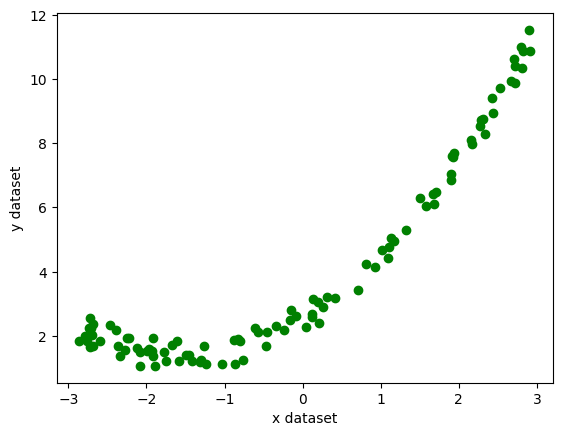

In [81]:
#this is for the non liner data 

#quadratic equation gives such form  ax^2+bx+y =0 just like gradient decent 

X = 6 * np.random.rand(100,1)-3
y = 0.5 * X**2 +1.5*X +2+np.random.rand(100,1) 
#this it my quadratic equation = y = 0.5x^21

plt.scatter(X,y,color='g')
plt.xlabel("x dataset")
plt.ylabel('y dataset')

In [82]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [83]:
from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()


In [84]:
regression_1.fit(X_train,Y_train)

LinearRegression()

In [85]:
from sklearn.metrics import r2_score
score = r2_score(Y_test,regression_1.predict(X_test))
print(score)

0.8003790811537904


Text(0, 0.5, 'Y')

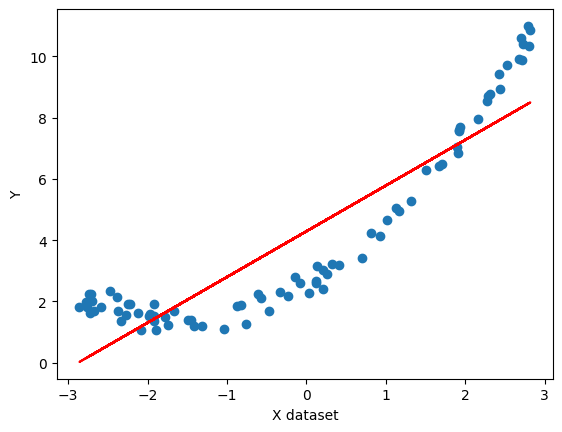

In [86]:
#Visualize the model

plt.plot(X_train,regression_1.predict(X_train),color ='r')
plt.scatter(X_train,Y_train)
plt.xlabel("X dataset")
plt.ylabel("Y")

In [87]:
#apply polinomial tranformation

from sklearn.preprocessing import PolynomialFeatures



In [88]:
poly = PolynomialFeatures(degree=3,include_bias=True)


In [89]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [90]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly,Y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(Y_test,y_pred)
print(score)

0.9903302560782096


In [91]:
print(regression.coef_)

[[0.         1.48884707 0.48767871 0.00666465]]


In [92]:
print(regression.intercept_)

[2.56842022]


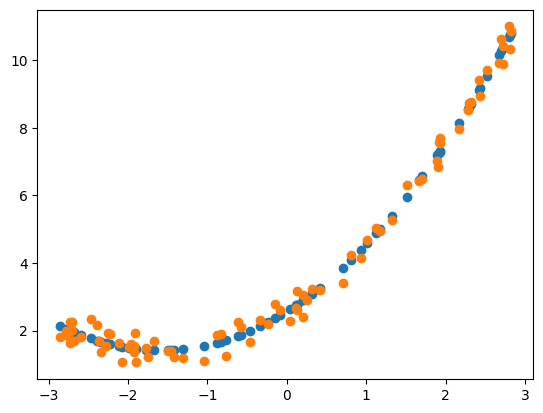

In [93]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,Y_train)

In [94]:
#perdict new data

x_new = np.linspace(-3,3,200).reshape(200,1)
x_new_poly = poly.transform(x_new)
x_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

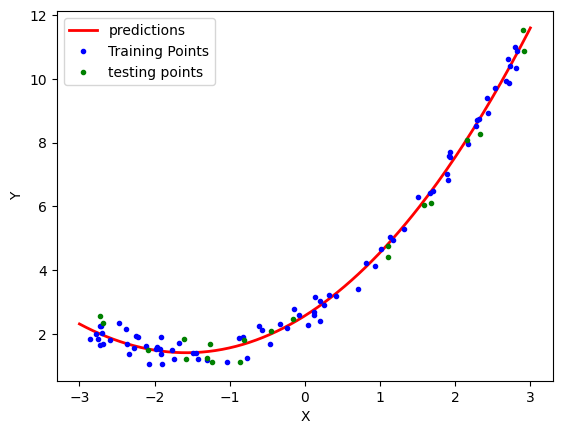

In [95]:
y_new = regression.predict(x_new_poly)
plt.plot(x_new,y_new,"r-",linewidth =2,label = 'predictions')
plt.plot(X_train,Y_train,"b.",label= "Training Points")
plt.plot(X_test,Y_test,"g.",label="testing points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

##Pipeline concept



In [103]:
from sklearn.pipeline import Pipeline


In [111]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,Y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
        #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, Y_train, "b.", linewidth=3)
    plt.plot(X_test, Y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()



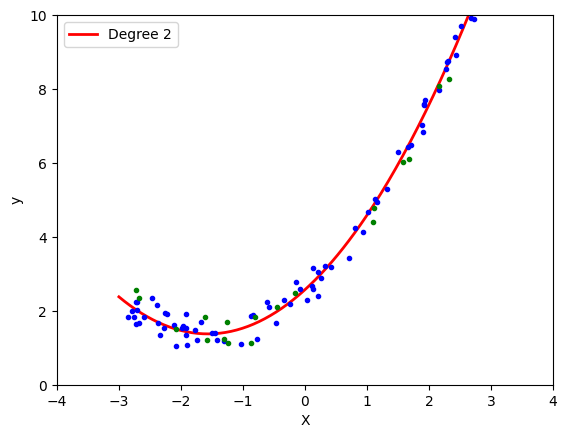

In [115]:
poly_regression(2)